In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Layer Enclosures

An **enclosure** defines how additional layers are generated *around* a core shape.
Common uses include:

- **Slab / cladding** — oxide or slab that surrounds a waveguide core.
- **Doping regions** — implant layers offset from a rib waveguide.
- **Keep-out zones** — exclusion regions around metal traces.
- **Floorplan** — bounding-box expansions that pad a component's outline.

kfactory implements two enclosure classes:

| Class | Applies to |
|---|---|
| `LayerEnclosure` | A single layer's geometry on a component |
| `KCellEnclosure` | An entire assembled `KCell` (merges sub-cell geometries) |

`LayerEnclosure` is the building block; `KCellEnclosure` wraps one or more
`LayerEnclosure` objects and applies them to a finished cell as a post-processing step.

## Setup

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)
    NPP: kf.kdb.LayerInfo = kf.kdb.LayerInfo(4, 0)
    METAL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 0)
    METALEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 1)


L = LAYER()
kf.kcl.infos = L

## 1 · Simple uniform expansion — cladding

The most common enclosure is a single layer that expands symmetrically around the
waveguide core.

```
sections = [(target_layer, expansion_dbu)]
```

A 2 µm WGCLAD around a WG core (1 nm/DBU → 2 µm = 2 000 DBU):

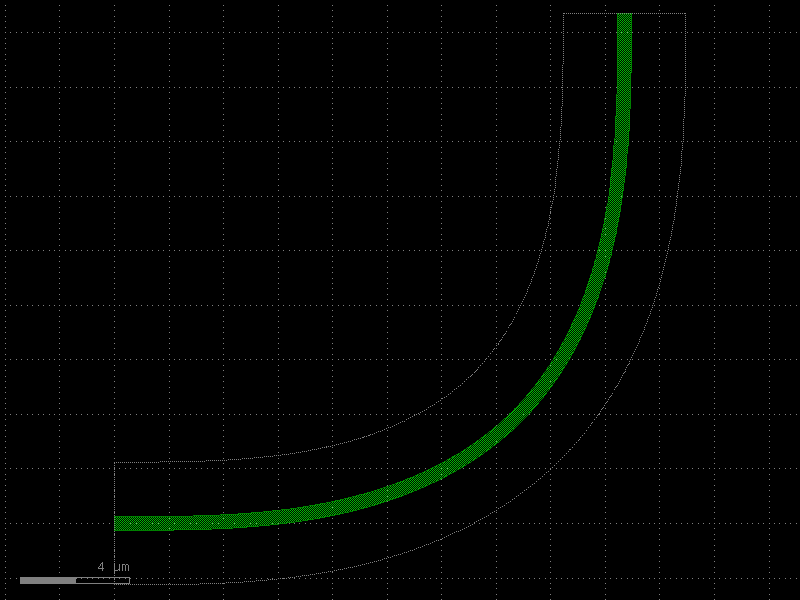

In [3]:
clad_enc = kf.LayerEnclosure(
    sections=[(L.WGCLAD, 2_000)],  # 2 µm cladding in DBU
    name="WGSTD",
    main_layer=L.WG,
)

# Create an Euler bend with cladding applied.
bend_with_clad = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=clad_enc,
    angle=90,
)
bend_with_clad.plot()

The WG core (layer 1/0) is drawn by the cell itself; the WGCLAD (layer 2/0) is
automatically computed as the Minkowski expansion of the WG shape.

## 2 · µm-based sections with `dsections`

Specifying DBU manually is error-prone when the grid resolution may change.
Use `dsections=` together with `kcl=` to specify distances in micrometres:

2026-07-07 06:59:37.263 | ERROR    | kfactory.kcell:name:818 - Name conflict in kfactory.kcell::name at line 818
Renaming Unnamed_2 (cell_index=2) to bend_euler_CS67c2bf20_500_R10_A90_R150 would cause it to be named the same as:
 - bend_euler_CS67c2bf20_500_R10_A90_R150 (cell_index=0), function_name=_bend_euler, basename=bend_euler


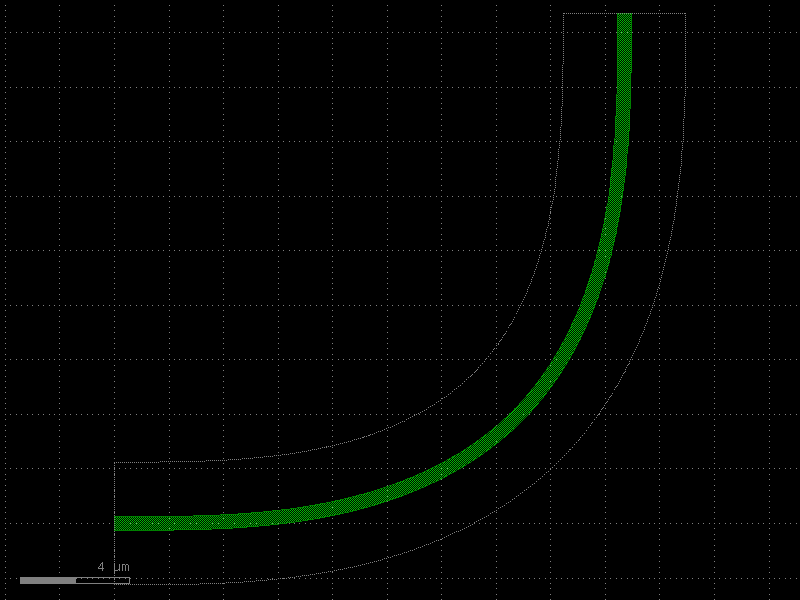

In [4]:
clad_enc_um = kf.LayerEnclosure(
    dsections=[(L.WGCLAD, 2.0)],  # 2 µm — converted to DBU automatically
    name="WGSTD_UM",
    main_layer=L.WG,
    kcl=kf.kcl,
)

bend_um = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=clad_enc_um,
    angle=90,
)
bend_um.plot()

## 3 · Multi-layer enclosures

A single `LayerEnclosure` can drive *multiple* output layers.  Each tuple in
`sections` specifies one rule.

### Two-element tuple — symmetric expansion

```python
(layer, d_max)          # expands by d_max DBU on all sides
```

### Three-element tuple — annular (ring) region

```python
(layer, d_min, d_max)   # inner edge at d_min, outer edge at d_max
```

This is useful for doping layers that must stay a minimum distance from the waveguide
edge:

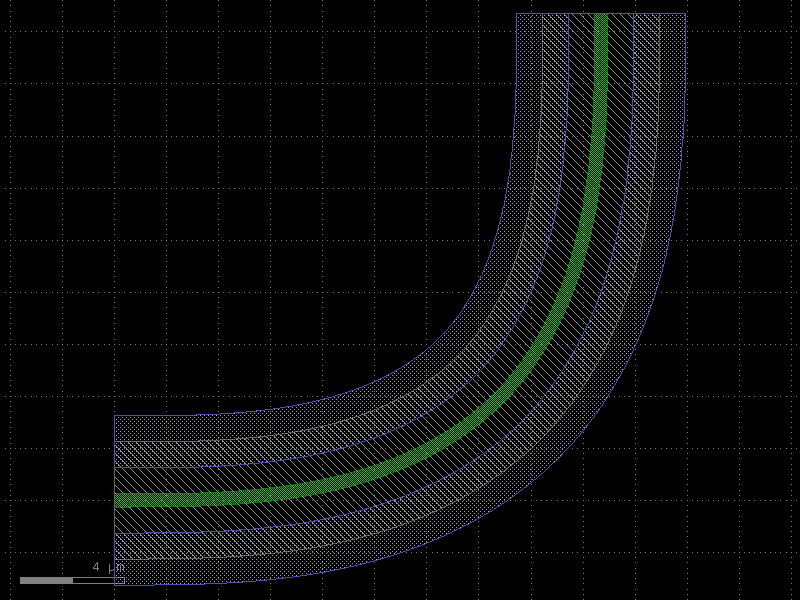

In [5]:
# SLAB: 2 µm uniform cladding.
# NPP:  implant ring, 1 µm from WG edge to 3 µm from WG edge.
doped_enc = kf.LayerEnclosure(
    dsections=[
        (L.SLAB, 2.0),  # 0 → 2 µm
        (L.NPP, 1.0, 3.0),  # 1 → 3 µm  (annular ring)
    ],
    name="SLAB_DOPED",
    main_layer=L.WG,
    kcl=kf.kcl,
)

bend_doped = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=doped_enc,
    angle=90,
)
bend_doped.plot()

Three layers are now present:
- **WG** (core waveguide)
- **SLAB** (uniform 2 µm expansion)
- **NPP** (annular implant from 1 µm to 3 µm outside the WG edge)

## 4 · Enclosures on straight waveguides and tapers

Enclosures work on any component factory that accepts an `enclosure=` argument.

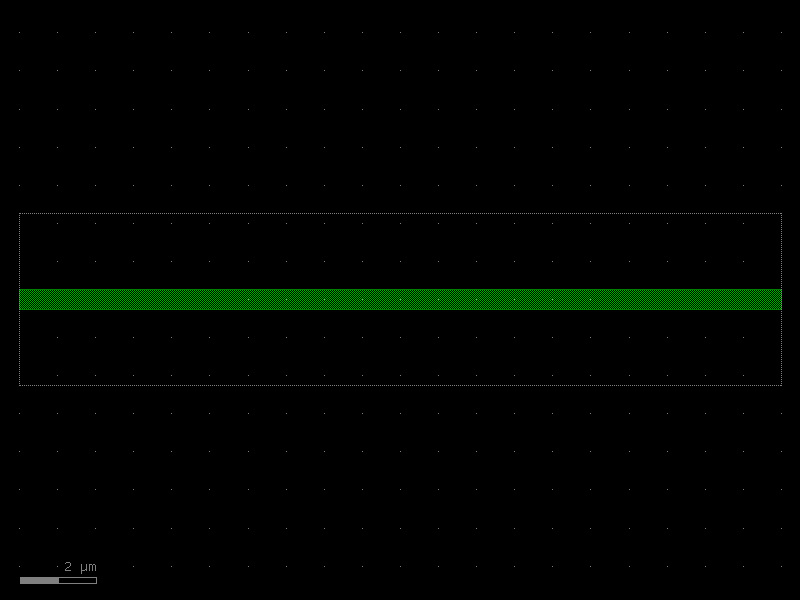

In [6]:
straight_with_enc = kf.factories.straight.straight_dbu_factory(kcl=kf.kcl)(
    width=kf.kcl.to_dbu(0.5),
    length=kf.kcl.to_dbu(20),
    layer=L.WG,
    enclosure=clad_enc,
)
straight_with_enc.plot()

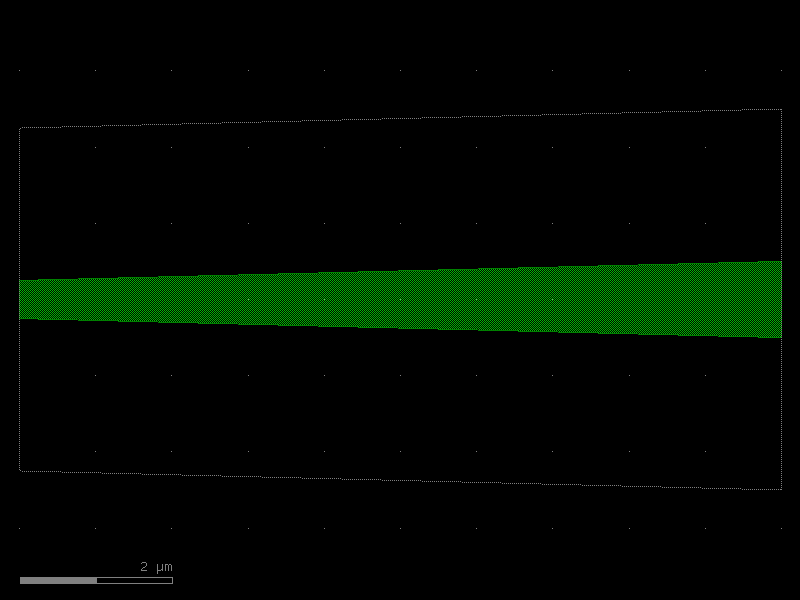

In [7]:
taper_with_enc = kf.factories.taper.taper_factory(kcl=kf.kcl)(
    width1=kf.kcl.to_dbu(0.5),
    width2=kf.kcl.to_dbu(1.0),
    length=kf.kcl.to_dbu(10),
    layer=L.WG,
    enclosure=clad_enc,
)
taper_with_enc.plot()

## 5 · `KCellEnclosure` — cell-level enclosures

When a cell contains *multiple* sub-components, applying a `LayerEnclosure` to each
sub-component separately leaves gaps at the joins.  `KCellEnclosure.apply_minkowski_tiled`
operates on the **merged** geometry of the finished cell, producing a single continuous
enclosure.

### Example: two-bend cell with unified cladding

2026-07-07 06:59:37.467 | ERROR    | kfactory.kcell:name:818 - Name conflict in kfactory.kcell::name at line 818
Renaming Unnamed_12 (cell_index=12) to bend_euler_CS028523d7_500_R10_A90_R150 would cause it to be named the same as:
 - bend_euler_CS028523d7_500_R10_A90_R150 (cell_index=11), function_name=_bend_euler, basename=bend_euler


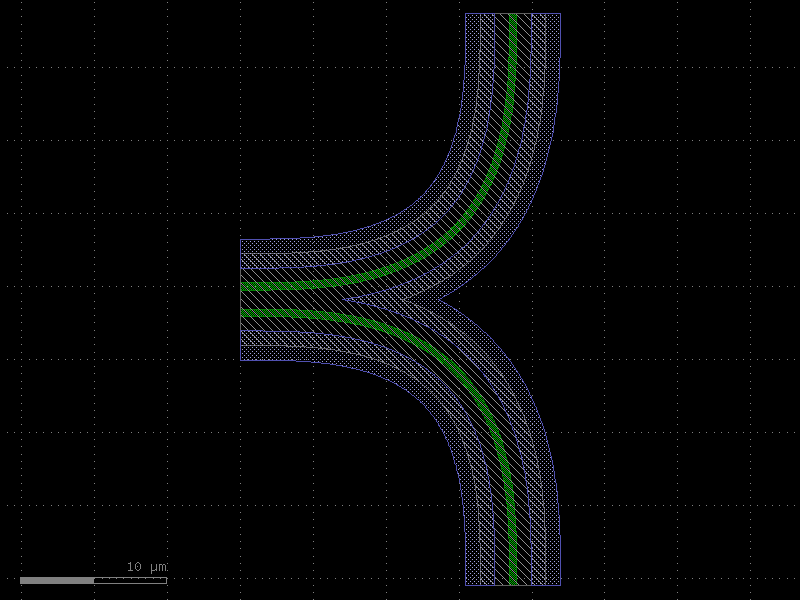

In [8]:
kcell_enc = kf.KCellEnclosure([doped_enc])


@kf.cell
def two_bends(
    radius: float,
    width: float,
    layer: kf.kdb.LayerInfo,
    enclosure: kf.KCellEnclosure | None = None,
) -> kf.KCell:
    """Two euler bends joined at their West ports, with optional cell-level enclosure."""
    c = kf.KCell()
    b1 = c << kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
        width=width, radius=radius, layer=layer, angle=90
    )
    b2 = c << kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
        width=width, radius=radius, layer=layer, angle=90
    )
    # Place b2 rotated 90° below b1
    b2.drotate(90)
    b2.dmovey(-radius * 2 - width)
    b2.dmovex(b2.dxmin, 0)

    c.add_ports(b1.ports)
    c.add_ports(b2.ports)
    c.auto_rename_ports()

    if enclosure:
        enclosure.apply_minkowski_tiled(c)
    return c


c_two = two_bends(radius=10, width=0.5, layer=L.WG, enclosure=kcell_enc)
c_two.plot()

Notice that the SLAB and NPP layers form a *single, continuous* region around both
bends, with no gap between them — this is the key advantage of `KCellEnclosure` over
per-component enclosures.

## 6 · `SymmetricalCrossSection` — reusable cross-section

For photonic PDKs, you typically want to encode the waveguide width, cladding, and
bend radius as a named, reusable object.  `SymmetricalCrossSection` bundles a width
(in DBU) with a `LayerEnclosure` into a single immutable value.

In [9]:
from kfactory.cross_section import SymmetricalCrossSection

wg_xs = SymmetricalCrossSection(
    width=kf.kcl.to_dbu(0.5),  # 500 nm core
    enclosure=clad_enc,
    name="WG_STD",
)

print(f"name:          {wg_xs.name}")
print(f"width (DBU):   {wg_xs.width}")
print(f"width (µm):    {kf.kcl.to_um(wg_xs.width):.3f}")
print(f"main_layer:    {wg_xs.main_layer}")

name:          WG_STD
width (DBU):   500
width (µm):    0.500
main_layer:    WG (1/0)


The cross-section is used by routing functions to automatically configure the straight
factory width and bend radius.  See the **Routing** section for examples.

## Summary

| Concept | Class | Key parameter |
|---|---|---|
| Uniform cladding | `LayerEnclosure` | `sections=[(layer, d_max)]` |
| Ring / annular region | `LayerEnclosure` | `sections=[(layer, d_min, d_max)]` |
| µm-specified distances | `LayerEnclosure` | `dsections=` + `kcl=` |
| Cell-level merged enclosure | `KCellEnclosure` | `.apply_minkowski_tiled(cell)` |
| Reusable width + enclosure | `SymmetricalCrossSection` | `width=`, `enclosure=` |

The typical PDK workflow is:
1. Define a `LayerEnclosure` for each waveguide type (strip, rib, metal, …).
2. Wrap it in a `SymmetricalCrossSection` with the nominal width and bend radius.
3. Pass the cross-section to routing functions — they handle everything else.

## See Also

| Topic | Where |
|-------|-------|
| Cross-sections (port geometry) | [Cross-Sections](cross_sections.py) |
| Cell-level enclosures (tiling) | [Enclosures: KCell Enclosure](kcell_enclosure.py) |
| Straight waveguide (uses enclosure) | [Components: Straight](../components/cells/factories/straight.py) |
| Width tapers (uses enclosure) | [Components: Tapers](../components/cells/factories/taper.py) |